# 05 — Modelado y construcción del Índice de Vulnerabilidad Educativa

Objetivo: entrenar un modelo de clasificación para identificar segmentos educativos
en riesgo alto de abandono, y construir un índice de vulnerabilidad continuo (0–100)
basado en las probabilidades predichas.

Modelo: Random Forest con class_weight='balanced'
Target: abandono_alto (1 = tasa_abandono > 1.2%, percentil 75)
Dataset: data/ml/dataset_modelo.csv (1.207 filas × 18 columnas)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')BASE = '..'

df = pd.read_csv(f'{BASE}/data/ml/dataset_museo.csv')

print(f"Shape: {df.shape}")
print(f"\nColumnas:\n{df.columns.tolist()}")
print(f"\nDistribución del target:")
print(df['abandono_alto'].value_counts())
print(f"\nPorcentaje:\n{df['abandono_alto'].value_counts(normalize=True).round(3) * 100}")

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


## 1. Carga del dataset

Se carga el dataset final preparado en la etapa de feature engineering.
Se verifica shape, columnas y distribución del target antes de continuar.

In [3]:
BASE = '..'

df = pd.read_csv(f'{BASE}/data/ml/dataset_modelo.csv')

print(f"Shape: {df.shape}")
print(f"\nColumnas:\n{df.columns.tolist()}")
print(f"\nDistribución del target:")
print(df['abandono_alto'].value_counts())
print(f"\nPorcentaje:\n{df['abandono_alto'].value_counts(normalize=True).round(3) * 100}")

Shape: (1207, 18)

Columnas:
['provincia', 'departamento', 'sector', 'ambito', 'matricula_total', 'tasa_repitencia', 'tasa_sobreedad', 'ratio_alumnos_seccion', 'tasa_abandono', 'abandono_alto', 'prop_electricidad', 'prop_equip_establecimiento', 'prop_equip_biblioteca', 'prop_internet_estatal', 'prop_conexion_aulas', 'prop_sin_cooperadora', 'prop_laboratorio', 'prop_biblioteca']

Distribución del target:
abandono_alto
0    906
1    301
Name: count, dtype: int64

Porcentaje:
abandono_alto
0    75.1
1    24.9
Name: proportion, dtype: float64


## 2. Definición de features y target

Se separan las columnas identificadoras (claves), las features y el target.
El split es 80/20 con stratify para mantener la proporción del desbalance en ambos conjuntos.

In [4]:
# Columnas clave — identifican el segmento, no entran al modelo
cols_clave = ['provincia', 'departamento', 'sector', 'ambito']

# Target
target = 'abandono_alto'

# Features — todo menos claves, target y tasa_abandono (de la que deriva el target)
cols_excluir = cols_clave + [target, 'tasa_abandono']
features = [col for col in df.columns if col not in cols_excluir]

print(f"Features ({len(features)}):\n{features}")
print(f"\nTarget: {target}")

# Split
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain: {X_train.shape} | Test: {X_test.shape}")
print(f"Distribución train:\n{y_train.value_counts(normalize=True).round(3) * 100}")
print(f"Distribución test:\n{y_test.value_counts(normalize=True).round(3) * 100}")

Features (12):
['matricula_total', 'tasa_repitencia', 'tasa_sobreedad', 'ratio_alumnos_seccion', 'prop_electricidad', 'prop_equip_establecimiento', 'prop_equip_biblioteca', 'prop_internet_estatal', 'prop_conexion_aulas', 'prop_sin_cooperadora', 'prop_laboratorio', 'prop_biblioteca']

Target: abandono_alto

Train: (965, 12) | Test: (242, 12)
Distribución train:
abandono_alto
0    75.0
1    25.0
Name: proportion, dtype: float64
Distribución test:
abandono_alto
0    75.2
1    24.8
Name: proportion, dtype: float64


## 3. Entrenamiento — Random Forest

Modelo principal. Se usa class_weight='balanced' para compensar el desbalance 75/25.
random_state=42 garantiza reproducibilidad.

In [5]:
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("=== Resultados Random Forest ===\n")
print(classification_report(y_test, y_pred, target_names=['Bajo riesgo', 'Alto riesgo']))

=== Resultados Random Forest ===

              precision    recall  f1-score   support

 Bajo riesgo       0.82      0.93      0.87       182
 Alto riesgo       0.65      0.37      0.47        60

    accuracy                           0.79       242
   macro avg       0.73      0.65      0.67       242
weighted avg       0.78      0.79      0.77       242



## 4. Ajuste de umbral de decisión

El umbral por defecto (0.5) produce recall bajo en la clase minoritaria.
Se ajusta el umbral para priorizar la detección de segmentos en riesgo alto,
aceptando más falsos positivos a cambio de menos falsos negativos.

In [6]:
# Probabilidades predichas (columna 1 = probabilidad de clase "alto riesgo")
y_proba = rf.predict_proba(X_test)[:, 1]

# Probar distintos umbrales
umbrales = [0.5, 0.4, 0.35, 0.3, 0.25]

print(f"{'Umbral':<10} {'Precision':<12} {'Recall':<10} {'F1':<10}")
print("-" * 42)

from sklearn.metrics import precision_score, recall_score, f1_score

for u in umbrales:
    y_pred_u = (y_proba >= u).astype(int)
    p = precision_score(y_test, y_pred_u)
    r = recall_score(y_test, y_pred_u)
    f = f1_score(y_test, y_pred_u)
    print(f"{u:<10} {p:<12.3f} {r:<10.3f} {f:<10.3f}")

Umbral     Precision    Recall     F1        
------------------------------------------
0.5        0.667        0.400      0.500     
0.4        0.673        0.617      0.643     
0.35       0.591        0.650      0.619     
0.3        0.550        0.733      0.629     
0.25       0.511        0.783      0.618     


## 5. Evaluación final con umbral ajustado

Se aplica el umbral 0.4 como punto de corte definitivo.
Mejor balance entre precision y recall para el caso de uso de priorización de intervenciones.

=== Resultados finales (umbral 0.4) ===

              precision    recall  f1-score   support

 Bajo riesgo       0.88      0.90      0.89       182
 Alto riesgo       0.67      0.62      0.64        60

    accuracy                           0.83       242
   macro avg       0.77      0.76      0.77       242
weighted avg       0.83      0.83      0.83       242



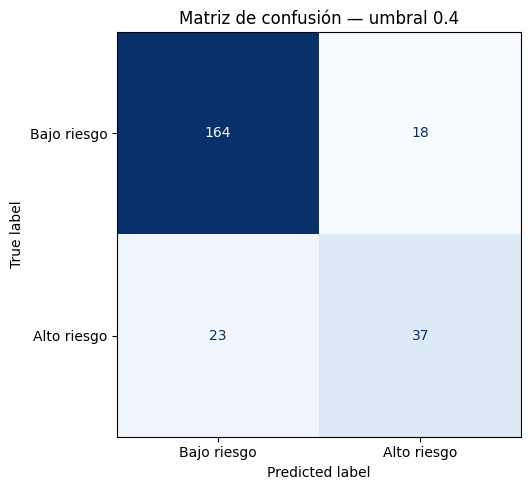

Guardado: outputs/11_confusion_matrix.png


In [7]:
UMBRAL = 0.4
y_pred_final = (y_proba >= UMBRAL).astype(int)

print("=== Resultados finales (umbral 0.4) ===\n")
print(classification_report(y_test, y_pred_final, target_names=['Bajo riesgo', 'Alto riesgo']))

# Matriz de confusión
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Bajo riesgo', 'Alto riesgo'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de confusión — umbral 0.4')
plt.tight_layout()
plt.savefig(f'{BASE}/outputs/11_confusion_matrix.png', dpi=150)
plt.show()
print("Guardado: outputs/11_confusion_matrix.png")

## 6. Importancia de features

Se extraen las importancias asignadas por el modelo a cada variable.
Esto permite identificar qué factores explican el riesgo de abandono
y es la base para construir el índice de vulnerabilidad.

                   feature  importancia
            tasa_sobreedad     0.158914
           tasa_repitencia     0.132367
       prop_conexion_aulas     0.112864
prop_equip_establecimiento     0.084359
     ratio_alumnos_seccion     0.080144
     prop_internet_estatal     0.077694
     prop_equip_biblioteca     0.074654
      prop_sin_cooperadora     0.074368
           matricula_total     0.068593
           prop_biblioteca     0.068132
          prop_laboratorio     0.051062
         prop_electricidad     0.016848


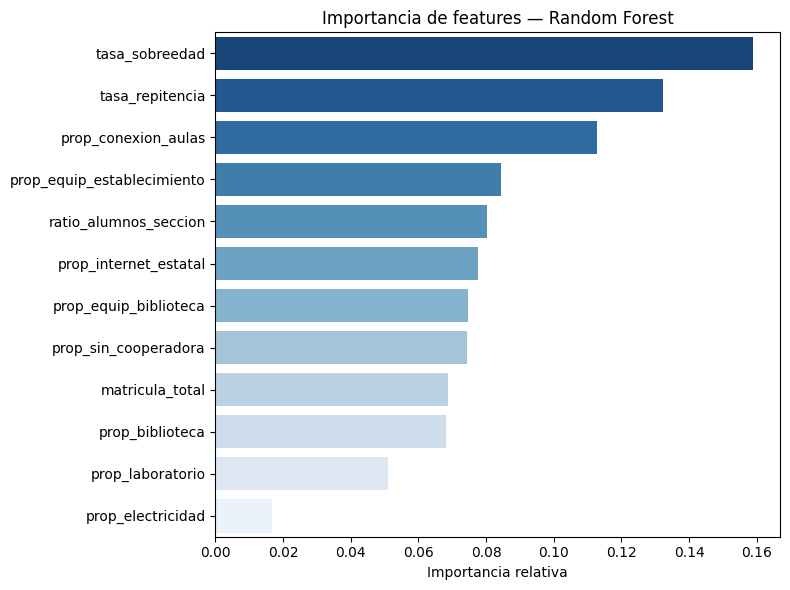

Guardado: outputs/12_importancia_features.png


In [8]:
importancias = pd.DataFrame({
    'feature': features,
    'importancia': rf.feature_importances_
}).sort_values('importancia', ascending=False).reset_index(drop=True)

print(importancias.to_string(index=False))

# Gráfico
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=importancias, x='importancia', y='feature', palette='Blues_r', ax=ax)
ax.set_title('Importancia de features — Random Forest')
ax.set_xlabel('Importancia relativa')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(f'{BASE}/outputs/12_importancia_features.png', dpi=150)
plt.show()
print("Guardado: outputs/12_importancia_features.png")

## ADVERTENCIA IMPORTANTE

 Importancia de features en Random Forest no significa causalidad. Significa que esa variable fue útil para separar clases. tasa_sobreedad predice abandono, pero eso no prueba que reducir sobreedad cause menor abandono — puede ser que ambas sean síntomas del mismo problema estructural subyacente.